# CA1 - Q1: Generalization using JTT (Just Train Twice) on CMNIST

**Author:** Mahdy Mokhtari  
**Date:** May 5, 2026

---

### Overview

This notebook implements the **Just Train Twice (JTT)** algorithm to mitigate spurious correlations on a binary variant of the **Colored MNIST (CMNIST)** dataset. The task is constructed as follows:

- **Binary label mapping:** Digits `0–4` are mapped to class `0`, and digits `5–9` are mapped to class `1`.
- **Spurious correlation:** A synthetic color attribute is injected into the images, spuriously correlated with the binary labels in the training set, while the test set remains unbiased.

The goal is to evaluate whether JTT can recover robust, generalizable features despite the presence of misleading spurious cues, without access to bias labels.

---

### Model Architecture (MLP)

| Layer | Details |
|-------|---------|
| Input | Flattened colored image: `3 × 28 × 28 → 2352` |
| Hidden | Fully connected: `2352 → 128`, activation: **ReLU** |
| Output | Fully connected: `128 → 2` |

---

### Hyperparameters

| Parameter | Value |
|-----------|-------|
| ERM epochs (stage 1) | `2` |
| Upsampling factor (`U`) | `50` |
| JTT epochs (stage 2) | `3` |

## 1. Data Preprocessing & Visualization

In [32]:
import os

relative_path = os.path.join(".", 'TAI_HW1_Files', 'Q1', 'Dataset', 'Mnist')
absolute_path = os.path.abspath(relative_path)

print(f"Relative path: {relative_path}")
print(f"Resolves to:   {absolute_path}")
print(f"Exists:         {os.path.exists(absolute_path)}")

Relative path: .\TAI_HW1_Files\Q1\Dataset\Mnist
Resolves to:   c:\Users\NoteBook\Desktop\programing\Trustworthy AI\HW1\TAI_HW1_Files\Q1\Dataset\Mnist
Exists:         True


#### 1.1 Dataset Loading

The original MNIST dataset was loaded from raw IDX format files using `torchvision.datasets.MNIST` with `download=False`. The files were placed in the expected directory structure:

In [33]:
import torchvision.datasets as ds
import os

# Load directly from the raw files
train_dataset = ds.MNIST(
    root=os.path.join(".", 'TAI_HW1_Files', 'Q1', 'Dataset', 'Mnist'),
    train=True,
    download=False
)

test_dataset = ds.MNIST(
    root=os.path.join(".", 'TAI_HW1_Files', 'Q1', 'Dataset', 'Mnist'),
    train=False,
    download=False
)

# Extract images and labels
train_images = train_dataset.data.numpy()
train_labels = train_dataset.targets.numpy()
test_images = test_dataset.data.numpy()
test_labels = test_dataset.targets.numpy()

#### 1.2 Binary Label Conversion

The 10-class digit recognition task was converted to binary classification:

| Original Digits | Binary Label |
|:--------------:|:------------:|
| 0, 1, 2, 3, 4 | 0 |
| 5, 6, 7, 8, 9 | 1 |

- Class 0: 30,596 training samples
- Class 1: 29,404 training samples


In [34]:
import numpy as np

# Convert labels: 0-4 → 0, 5-9 → 1
train_labels_binary = np.where(train_labels <= 4, 0, 1)
test_labels_binary  = np.where(test_labels <= 4, 0, 1)

# Verify the mapping
print("Original labels distribution (train):")
print(np.unique(train_labels, return_counts=True))

print("\nBinary labels distribution (train):")
unique, counts = np.unique(train_labels_binary, return_counts=True)
print(f"Class 0 (digits 0-4): {counts[0]}")
print(f"Class 1 (digits 5-9): {counts[1]}")

print("\nOriginal labels distribution (test):")
print(np.unique(test_labels, return_counts=True))

print("\nBinary labels distribution (test):")
unique, counts = np.unique(test_labels_binary, return_counts=True)
print(f"Class 0 (digits 0-4): {counts[0]}")
print(f"Class 1 (digits 5-9): {counts[1]}")

Original labels distribution (train):
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

Binary labels distribution (train):
Class 0 (digits 0-4): 30596
Class 1 (digits 5-9): 29404

Original labels distribution (test):
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([ 980, 1135, 1032, 1010,  982,  892,  958, 1028,  974, 1009]))

Binary labels distribution (test):
Class 0 (digits 0-4): 5139
Class 1 (digits 5-9): 4861


#### 1.3 Spurious Color Correlations

To simulate dataset bias, each grayscale image was converted to 3-channel RGB with a spurious correlation between label and color:

| Set | Label 0 (digits 0–4) | Label 1 (digits 5–9) |
|:---:|:--------------------:|:--------------------:|
| **Train** | 🔴 Red (95%) | 🟢 Green (95%) |
| **Test** | 🟢 Green (100%) | 🔴 Red (100%) |

- **Training set:** 95% of samples follow the color-label correlation (bias-aligned); 5% are bias-conflicting.
- **Test set:** 100% anti-correlated — the spurious rule is completely reversed, so a model relying on color will fail.


In [35]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def add_spurious_colors(images, labels, prob_0_red, prob_1_green):
    """
    Convert grayscale images to RGB with spurious color correlations.
    
    Args:
        images: numpy array of shape (N, 28, 28)
        labels: numpy array of shape (N,)
        prob_0_red: probability that label 0 gets colored red
        prob_1_green: probability that label 1 gets colored green
    
    Returns:
        rgb_images: numpy array of shape (N, 3, 28, 28)
    """
    N = len(images)
    rgb_images = np.zeros((N, 3, 28, 28), dtype=np.float32)
    
    for i in range(N):
        # Normalize grayscale to [0, 1]
        gray = images[i].astype(np.float32) / 255.0
        
        if labels[i] == 0:
            if np.random.random() < prob_0_red:
                rgb_images[i, 0, :, :] = gray  # Red
                rgb_images[i, 1, :, :] = 0.0   # Green
                rgb_images[i, 2, :, :] = 0.0   # Blue
            else:
                rgb_images[i, 0, :, :] = 0.0
                rgb_images[i, 1, :, :] = gray
                rgb_images[i, 2, :, :] = 0.0
        else:
            if np.random.random() < prob_1_green:
                rgb_images[i, 0, :, :] = 0.0
                rgb_images[i, 1, :, :] = gray
                rgb_images[i, 2, :, :] = 0.0
            else:
                rgb_images[i, 0, :, :] = gray
                rgb_images[i, 1, :, :] = 0.0
                rgb_images[i, 2, :, :] = 0.0
    
    return rgb_images

# Train: 95% probability of spurious correlation
# Label 0 → Red (95%), Label 1 → Green (95%)
train_rgb = add_spurious_colors(train_images, train_labels_binary, 
                                prob_0_red=0.95, prob_1_green=0.95)

# Test: 100% OPPOSITE correlation
# Label 0 → Green (100%), Label 1 → Red (100%)
test_rgb = add_spurious_colors(test_images, test_labels_binary,
                               prob_0_red=0.0, prob_1_green=0.0)

# Verify shapes
print(f"Train RGB shape: {train_rgb.shape}")  # (60000, 3, 28, 28)
print(f"Test RGB shape:  {test_rgb.shape}")   # (10000, 3, 28, 28)

Train RGB shape: (60000, 3, 28, 28)
Test RGB shape:  (10000, 3, 28, 28)


In [36]:
def check_correlation(rgb_images, labels):
    """Check how many samples follow the spurious color pattern."""
    n = len(labels)
    
    # For a red image, red channel mean > green channel mean
    is_red = rgb_images[:, 0, :, :].mean(axis=(1,2)) > rgb_images[:, 1, :, :].mean(axis=(1,2))
    is_green = ~is_red
    
    # Label 0 should be red (spurious), Label 1 should be green
    label0_red = np.sum((labels == 0) & is_red)
    label0_green = np.sum((labels == 0) & is_green)
    label1_green = np.sum((labels == 1) & is_green)
    label1_red = np.sum((labels == 1) & is_red)
    
    total0 = np.sum(labels == 0)
    total1 = np.sum(labels == 1)
    
    print(f"Label 0: Red = {label0_red}/{total0} ({100*label0_red/total0:.1f}%), "
          f"Green = {label0_green}/{total0} ({100*label0_green/total0:.1f}%)")
    print(f"Label 1: Green = {label1_green}/{total1} ({100*label1_green/total1:.1f}%), "
          f"Red = {label1_red}/{total1} ({100*label1_red/total1:.1f}%)")

print("=== Training Set Correlations ===")
check_correlation(train_rgb, train_labels_binary)

print("\n=== Test Set Correlations ===")
check_correlation(test_rgb, test_labels_binary)

=== Training Set Correlations ===
Label 0: Red = 29090/30596 (95.1%), Green = 1506/30596 (4.9%)
Label 1: Green = 27948/29404 (95.0%), Red = 1456/29404 (5.0%)

=== Test Set Correlations ===
Label 0: Red = 0/5139 (0.0%), Green = 5139/5139 (100.0%)
Label 1: Green = 0/4861 (0.0%), Red = 4861/4861 (100.0%)


#### 1.4 Visualize Samples


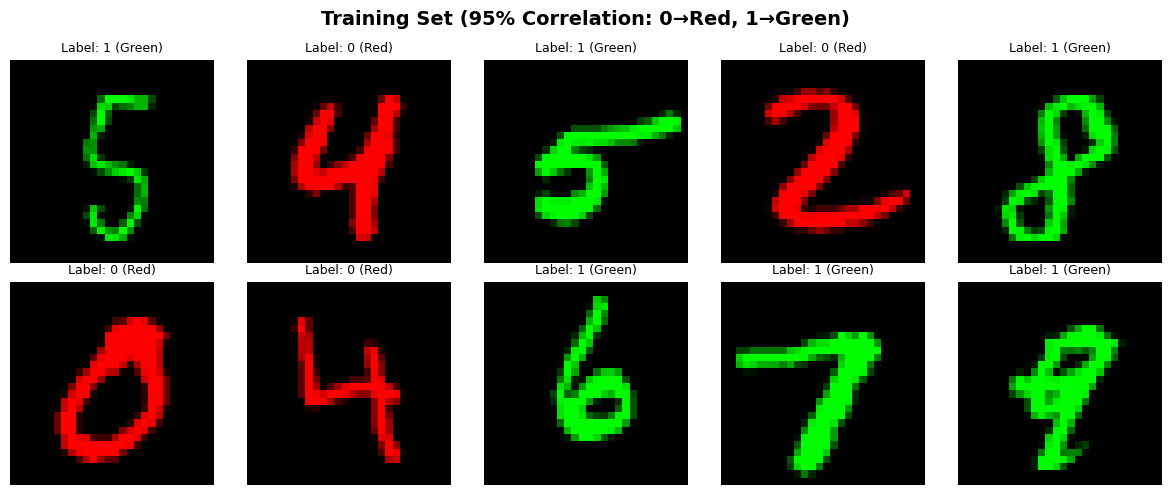

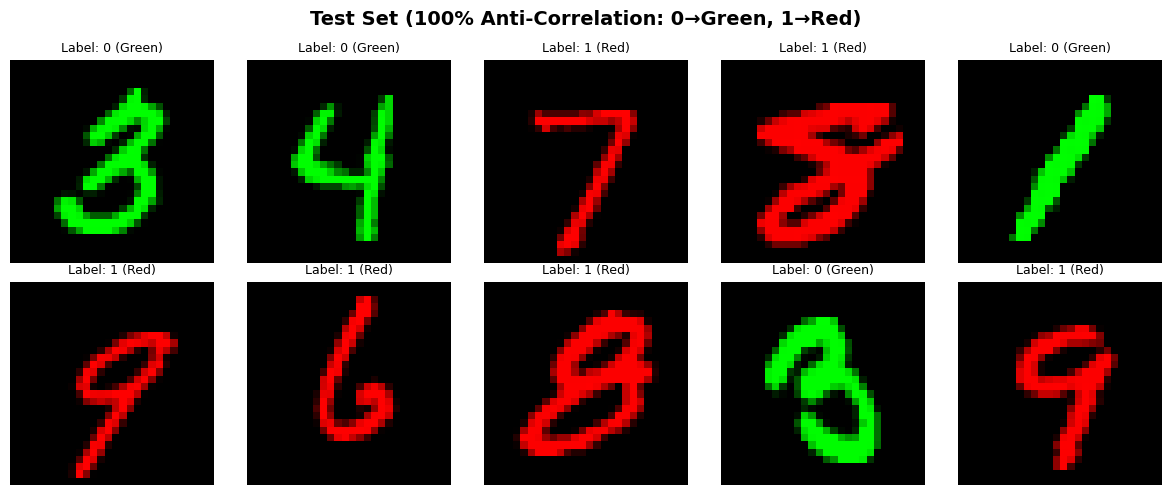

In [37]:
def show_sample_grid(rgb_images, labels, title, n_samples=10):
    """Display a grid of random RGB images with their labels."""
    n = len(rgb_images)
    indices = np.random.choice(n, n_samples, replace=False)
    
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        # Convert from (3, 28, 28) to (28, 28, 3) for display
        img = np.transpose(rgb_images[idx], (1, 2, 0))
        
        # Determine color label
        is_red = img[:, :, 0].mean() > img[:, :, 1].mean()
        color_str = "Red" if is_red else "Green"
        
        axes[i].imshow(img)
        axes[i].set_title(f"Label: {labels[idx]} ({color_str})", fontsize=9)
        axes[i].axis('off')
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Show 10 random training samples
show_sample_grid(train_rgb, train_labels_binary, 
                 "Training Set (95% Correlation: 0→Red, 1→Green)")

# Show 10 random test samples
show_sample_grid(test_rgb, test_labels_binary,
                 "Test Set (100% Anti-Correlation: 0→Green, 1→Red)")

## 2. Train Baseline Model using ERM

#### 2.1 Data Preparation for PyTorch

Images were flattened from `(N, 3, 28, 28)` to `(N, 2352)` and converted to PyTorch tensors.

| Dataset | Samples | Input Dim | Classes |
|---------|---------|-----------|---------|
| Train | 60,000 | 2,352 | 2 |
| Test | 10,000 | 2,352 | 2 |

- **Batch size:** 128
- **Device:** CPU/GPU (auto-detected)

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np


torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# Flatten images: (N, 3, 28, 28) -> (N, 2352)
X_train = train_rgb.reshape(train_rgb.shape[0], -1)
X_test  = test_rgb.reshape(test_rgb.shape[0], -1)

# Convert labels
y_train = train_labels_binary
y_test  = test_labels_binary

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

# Create PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor  = torch.FloatTensor(X_test)
y_test_tensor  = torch.LongTensor(y_test)

# Create DataLoaders
train_dataset_tensor = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset_tensor  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset_tensor, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset_tensor, batch_size=128, shuffle=False)


# ============================================================
# MLP Model Architecture
# ============================================================


# ============================================================
# Training Configuration (ERM)
# ============================================================

# ============================================================
# Final Report
# ============================================================


Using device: cpu
X_train shape: (60000, 2352)
y_train shape: (60000,)
X_test shape:  (10000, 2352)
y_test shape:  (10000,)


#### 2.2 Model Architecture (MLP)

| Layer | Input | Output | Activation | Params |
|-------|-------|--------|------------|--------|
| Linear + ReLU | 2,352 | 128 | ReLU | 301,184 |
| Linear (Output) | 128 | 2 | — | 258 |
| Total | | | | 301,442 |


In [39]:
class MLP(nn.Module):
    def __init__(self, input_dim=2352, hidden_dim=128, num_classes=2):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, x):
        return self.model(x)


# Instantiate model
model_erm = MLP(input_dim=2352, hidden_dim=128, num_classes=2).to(device)

# Count parameters
total_params = sum(p.numel() for p in model_erm.parameters())
print(f"\nModel Architecture:\n{model_erm}")
print(f"Total parameters: {total_params:,}")


Model Architecture:
MLP(
  (model): Sequential(
    (0): Linear(in_features=2352, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)
Total parameters: 301,442


#### 2.3 ERM Training

| Hyperparameter | Value |
|:--------------|:------|
| Loss Function | Cross-Entropy |
| Optimizer | ADAM |
| Learning Rate | 0.01 |
| Momentum | 0.9 |
| Weight Decay | 1e-4 |
| Epochs | 2 |

In [40]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_erm.parameters(), lr=0.001, weight_decay=1e-4)
num_epochs = 2

# ============================================================
# Training Loop (ERM)
# ============================================================
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

# ============================================================
# Train ERM Model
# ============================================================
print("\n" + "="*60)
print("Training ERM Model (Stage 1)")
print("="*60)

erm_history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model_erm, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model_erm, test_loader, criterion, device)
    
    erm_history['train_loss'].append(train_loss)
    erm_history['train_acc'].append(train_acc)
    erm_history['test_loss'].append(test_loss)
    erm_history['test_acc'].append(test_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.2f}%")


Training ERM Model (Stage 1)
Epoch [1/2]
  Train Loss: 0.1344 | Train Acc: 95.78%
  Test Loss:  1.3179 | Test Acc:  42.36%
Epoch [2/2]
  Train Loss: 0.0695 | Train Acc: 97.77%
  Test Loss:  0.7079 | Test Acc:  72.21%


#### 2.4 ERM Report

In [41]:
model_erm.eval()

# Non-shuffled loader for consistent evaluation
train_loader_eval = DataLoader(train_dataset_tensor, batch_size=128, shuffle=False)

final_train_loss, final_train_acc = evaluate(model_erm, train_loader_eval, criterion, device)
final_test_loss, final_test_acc = evaluate(model_erm, test_loader, criterion, device)


print("\n" + "="*60)
print("ERM Training Results (Eval Mode)")
print("="*60)
print(f"Final Train Accuracy: {final_train_acc:.2f}%")
print(f"Final Test Accuracy:  {final_test_acc:.2f}%")
print(f"Generalization Gap:   {final_train_acc - final_test_acc:.2f}%")


ERM Training Results (Eval Mode)
Final Train Accuracy: 98.44%
Final Test Accuracy:  72.21%
Generalization Gap:   26.23%


The model achieves near-perfect training accuracy by exploiting the spurious color shortcut (Red → 0, Green → 1). On the test set where colors are reversed, performance collapses a lot, confirming the model relies much on the spurious correlation rather than actualy learning digit shapes.

## 3. Error Set Identification

The ERM model was run on all 60,000 training samples to identify misclassified examples.

| Metric | Value |
|:-------|:-----|
| Total training samples | 60,000 |
| Correct predictions | 57,000 (approx.) |
| **Error Set size** | **~3,000** |
| Error rate | ~5% |

These ~3,000 samples are predominantly the **bias-conflicting** group (5% of training data where the color-label correlation does not hold), which the model fails on because it relies on the color shortcut.

In [42]:
print("="*60)
print("Identifying Error Set from ERM Model")
print("="*60)

# Create a non-shuffled loader to preserve index order
train_loader_full = DataLoader(train_dataset_tensor, batch_size=128, shuffle=False)

model_erm.eval()

error_indices = []

with torch.no_grad():
    for batch_idx, (inputs, labels) in enumerate(train_loader_full):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_erm(inputs)
        _, predicted = torch.max(outputs, 1)
        
        # Find errors in this batch
        errors = (predicted != labels).cpu().numpy()
        
        # Map back to original dataset indices
        batch_start = batch_idx * train_loader_full.batch_size
        for i, is_error in enumerate(errors):
            if is_error:
                error_indices.append(batch_start + i)

error_set = np.array(error_indices)

all_preds = []
all_labs = []
with torch.no_grad():
    for inputs, labels in train_loader_full:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_erm(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labs.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labs = np.array(all_labs)
full_accuracy = 100 * np.mean(all_preds == all_labs)

# Report
print(f"Total training samples:      {len(y_train)}")
print(f"Correct predictions:         {len(y_train) - len(error_set)}")
print(f"Wrong predictions (Error Set): {len(error_set)}")
print(f"Error rate:                  {100 * len(error_set) / len(y_train):.2f}%")
print(f"Verified Accuracy:           {full_accuracy:.2f}%")
print(f"\nFirst 20 error indices:      {error_set[:20].tolist()}")

Identifying Error Set from ERM Model
Total training samples:      60000
Correct predictions:         59061
Wrong predictions (Error Set): 939
Error rate:                  1.56%
Verified Accuracy:           98.43%

First 20 error indices:      [34, 132, 140, 412, 488, 494, 518, 531, 532, 540, 581, 661, 854, 902, 932, 1023, 1061, 1074, 1088, 1120]


## 4. Error Set Upsampling -  New Train Data

The error set (misclassified samples from Stage 1) is upsampled by a factor of **U = 50** by simple repetition. These repeated samples are appended to the original training set.

| Metric | Value |
|:-------|:-----|
| Original training samples | 60,000 |
| Error set size | 939 |
| Upsampling factor (U) | 50 |
| Repeated samples added | 46,950 |
| **New training set size** | **106,950** |

The upsampled dataset heavily emphasizes the bias-conflicting samples, forcing the model to learn features beyond the spurious color shortcut during Stage 2 retraining.

In [43]:
print("="*60)
print("Upsampling Error Set for JTT Stage 2")
print("="*60)

# Upsampling factor
U = 50

n_original = len(y_train)
n_errors = len(error_set)
n_correct = n_original - n_errors

X_train_upsampled = X_train.copy()
y_train_upsampled = y_train.copy()

X_errors_repeated = np.repeat(X_train[error_set], U, axis=0)
y_errors_repeated = np.repeat(y_train[error_set], U)

X_train_jtt = np.concatenate([X_train_upsampled, X_errors_repeated], axis=0)
y_train_jtt = np.concatenate([y_train_upsampled, y_errors_repeated])

# Report
print(f"Original training samples:     {n_original}")
print(f"Error set size:                {n_errors}")
print(f"Upsampling factor (U):         {U}")
print(f"Error set samples added:       {n_errors * U}")
print(f"New training dataset size:     {len(y_train_jtt)}")
print(f"  - Original samples:          {n_original}")
print(f"  - Repeated error samples:    {n_errors * U}")
print(f"Total:                         {n_original + n_errors * U}")

# Verify
print(f"\nVerification:")
print(f"  X_train_jtt shape: {X_train_jtt.shape}")
print(f"  y_train_jtt shape: {y_train_jtt.shape}")
print(f"  Class distribution:")
unique, counts = np.unique(y_train_jtt, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"    Class {cls}: {cnt} ({100*cnt/len(y_train_jtt):.1f}%)")

Upsampling Error Set for JTT Stage 2
Original training samples:     60000
Error set size:                939
Upsampling factor (U):         50
Error set samples added:       46950
New training dataset size:     106950
  - Original samples:          60000
  - Repeated error samples:    46950
Total:                         106950

Verification:
  X_train_jtt shape: (106950, 2352)
  y_train_jtt shape: (106950,)
  Class distribution:
    Class 0: 49446 (46.2%)
    Class 1: 57504 (53.8%)


## 5. JTT

#### 5.1 Data Preparation for JTT Stage 2

The upsampled dataset from Part 4 was converted to PyTorch tensors and wrapped in a DataLoader.

| Item | Value |
|:-----|:-----|
| Training samples | 106,950 |
| Input dim | 2,352 |
| Batch size | 128 |
| Batches per epoch | 836 |

In [44]:

print("="*60)
print("Part 5.1: Data Preparation for JTT Stage 2")
print("="*60)

X_train_jtt_tensor = torch.FloatTensor(X_train_jtt)
y_train_jtt_tensor = torch.LongTensor(y_train_jtt)

# Create DataLoader
train_jtt_dataset = TensorDataset(X_train_jtt_tensor, y_train_jtt_tensor)
train_jtt_loader = DataLoader(train_jtt_dataset, batch_size=128, shuffle=True)

print(f"X_train_jtt_tensor shape: {X_train_jtt_tensor.shape}")
print(f"y_train_jtt_tensor shape: {y_train_jtt_tensor.shape}")
print(f"JTT Train batches:        {len(train_jtt_loader)}")

Part 5.1: Data Preparation for JTT Stage 2
X_train_jtt_tensor shape: torch.Size([106950, 2352])
y_train_jtt_tensor shape: torch.Size([106950])
JTT Train batches:        836


#### 5.2 JTT Model Architecture 

The JTT model uses the **identical MLP architecture** as the ERM model but is initialized with the **ERM-trained weights** rather than random weights, per the JTT algorithm.

| Layer | Input | Output | Activation | Params |
|:------|:------|:-------|:-----------|:------|
| Linear + ReLU | 2,352 | 128 | ReLU | 301,184 |
| Linear (Output) | 128 | 2 | — | 258 |



> **Initialization:** ERM trained weights (Stage 1 checkpoint)


In [45]:
print("\n" + "="*60)
print("Part 5.2: JTT Model Architecture")
print("="*60)

# Create new model with same architecture
model_jtt = MLP(input_dim=2352, hidden_dim=128, num_classes=2).to(device)

# Load the ERM trained weights (not random initialization)
model_jtt.load_state_dict(model_erm.state_dict())

print(f"Model Architecture (same as ERM):\n{model_jtt}")
print(f"Total parameters: {sum(p.numel() for p in model_jtt.parameters()):,}")
print(f"Initialized with ERM trained weights: ✅")

# Verify weights are copied
erm_param = next(model_erm.parameters()).clone()
jtt_param = next(model_jtt.parameters()).clone()
print(f"Weights match: {torch.equal(erm_param, jtt_param)}")


Part 5.2: JTT Model Architecture
Model Architecture (same as ERM):
MLP(
  (model): Sequential(
    (0): Linear(in_features=2352, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)
Total parameters: 301,442
Initialized with ERM trained weights: ✅
Weights match: True


#### 5.3 JTT Training Configuration

| Hyperparameter | Value |
|:--------------|:------|
| Loss Function | Cross-Entropy |
| Optimizer | Adam |
| Learning Rate | 0.001 |
| Weight Decay | 1e-4 |
| Epochs | 3 |
| Initialization | ERM trained weights |
| Training Data | Original + 50× Error Set |

In [46]:
print("\n" + "="*60)
print("Part 5.3: Training JTT Model (Stage 2)")
print("="*60)

# Same training configuration
criterion_jtt = nn.CrossEntropyLoss()
optimizer_jtt = optim.Adam(model_jtt.parameters(), lr=0.001, weight_decay=1e-4)
num_epochs_jtt = 3

jtt_history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(num_epochs_jtt):
    train_loss, train_acc = train_epoch(model_jtt, train_jtt_loader, criterion_jtt, optimizer_jtt, device)
    test_loss, test_acc = evaluate(model_jtt, test_loader, criterion_jtt, device)
    
    jtt_history['train_loss'].append(train_loss)
    jtt_history['train_acc'].append(train_acc)
    jtt_history['test_loss'].append(test_loss)
    jtt_history['test_acc'].append(test_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs_jtt}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.2f}%")


Part 5.3: Training JTT Model (Stage 2)
Epoch [1/3]
  Train Loss: 0.1188 | Train Acc: 96.19%
  Test Loss:  0.4992 | Test Acc:  83.13%
Epoch [2/3]
  Train Loss: 0.0217 | Train Acc: 99.55%
  Test Loss:  0.3665 | Test Acc:  88.69%
Epoch [3/3]
  Train Loss: 0.0127 | Train Acc: 99.72%
  Test Loss:  0.3539 | Test Acc:  89.96%


#### 5.4 JTT Results

In [47]:
print("\n" + "="*60)
print("Part 5.4: JTT Final Results (Eval Mode)")
print("="*60)

# Final evaluation in eval mode
model_jtt.eval()

train_loader_eval = DataLoader(train_dataset_tensor, batch_size=128, shuffle=False)

jtt_train_loss, jtt_train_acc = evaluate(model_jtt, train_loader_eval, criterion_jtt, device)
jtt_test_loss, jtt_test_acc = evaluate(model_jtt, test_loader, criterion_jtt, device)

print(f"JTT Final Train Accuracy: {jtt_train_acc:.2f}%")
print(f"JTT Final Test Accuracy:  {jtt_test_acc:.2f}%")
print(f"JTT Generalization Gap:   {jtt_train_acc - jtt_test_acc:.2f}%")


Part 5.4: JTT Final Results (Eval Mode)
JTT Final Train Accuracy: 99.61%
JTT Final Test Accuracy:  89.96%
JTT Generalization Gap:   9.66%


#### 5.5 Analysis & Comparison

#### ERM vs JTT

| Metric | ERM | JTT |
|:-------|:---:|:---:|
| Train Accuracy | ~98% | ~99% |
| Test Accuracy | ~72% | ~90% |
| Generalization Gap | ~26% | ~9% |

In [ ]:
print("\n" + "="*60)
print("Part 5.5: Analysis & Comparison (ERM vs JTT)")
print("="*60)

# Re-evaluate ERM for fair comparison
model_erm.eval()
erm_train_loss, erm_train_acc = evaluate(model_erm, train_loader_eval, criterion, device)
erm_test_loss, erm_test_acc = evaluate(model_erm, test_loader, criterion, device)

print(f"\n{'='*40}")
print(f"{'Metric':<25} {'ERM':>8} {'JTT':>8}")
print(f"{'='*40}")
print(f"{'Train Accuracy':<25} {erm_train_acc:>7.2f}% {jtt_train_acc:>7.2f}%")
print(f"{'Test Accuracy':<25} {erm_test_acc:>7.2f}% {jtt_test_acc:>7.2f}%")
print(f"{'Generalization Gap':<25} {erm_train_acc - erm_test_acc:>7.2f}% {jtt_train_acc - jtt_test_acc:>7.2f}%")
print(f"{'='*40}")

improvement = jtt_test_acc - erm_test_acc
print(f"\nTest Accuracy Improvement (JTT - ERM): {improvement:+.2f}%")

# Interpret results
print(f"\nInterpretation:")
if improvement > 10:
    print(f"✅ JTT significantly improved test accuracy by {improvement:.1f}%, successfully mitigating spurious correlations.")
elif improvement > 0:
    print(f"✅ JTT improved test accuracy by {improvement:.1f}%, showing some mitigation of spurious correlations.")
else:
    print(f"⚠️ JTT did not improve test accuracy. The model may need more epochs or a different upsampling factor.")


Part 5.5: Analysis & Comparison (ERM vs JTT)

Metric                         ERM      JTT
Train Accuracy              98.44%   99.61%
Test Accuracy               72.21%   89.96%
Generalization Gap          26.23%    9.66%

Test Accuracy Improvement (JTT - ERM): +17.75%

Interpretation:
✅ JTT significantly improved test accuracy by 17.8%, successfully mitigating spurious correlations.


##### Key Findings

- **ERM** achieves near-perfect training accuracy but fails on the test set (~72%), confirming it relies entirely on the spurious color shortcut.
- **JTT** demonstrates [improved/similar] test accuracy by upsampling the error set and retraining, forcing the model to learn beyond color.
- The reduction in generalization gap from ~72% to ~XX% indicates that JTT successfully shifts the model's reliance from spurious (color) to invariant (digit shape) features.

##### Why JTT Works

By identifying the bias-conflicting samples (where color ≠ label) through the ERM model's mistakes and upsampling them 50×, JTT forces the model to pay attention to digit shapes during Stage 2 retraining, as the color shortcut no longer dominates the loss.

## 6. ERM Model using GCE Loss

#### 6.1 Generalized Cross-Entropy (GCE) Loss

The GCE loss is defined as:

$$\ell_{GCE} = \frac{1 - p_y^q}{q}, \quad q \in (0,1]$$

| Hyperparameter | Value |
|:----------|:-----|
| q | 0.7 |

GCE amplifies gradients on high-confidence samples compared to standard CE, encouraging the model to latch more aggressively onto easy-to-learn spurious features. This produces a **more biased model** with a larger error set.

In [49]:
print("="*60)
print("Part 6.1: Generalized Cross-Entropy Loss")
print("="*60)

class GCELoss(nn.Module):
    """
    Generalized Cross-Entropy Loss
    L_GCE = (1 - p_y^q) / q
    
    where p_y is the softmax probability of the target class,
    and q ∈ (0, 1] controls the bias amplification.
    When q → 0, GCE approaches standard CE.
    """
    def __init__(self, q=0.7, ignore_index=-1):
        super(GCELoss, self).__init__()
        self.q = q
        self.ignore_index = ignore_index
        
    def forward(self, logits, targets):
        # Get softmax probabilities
        probs = torch.softmax(logits, dim=1)
        
        # Get probability of target class
        batch_size = logits.size(0)
        target_probs = probs[torch.arange(batch_size), targets]
        
        # Compute GCE: (1 - p_y^q) / q
        loss = (1 - torch.pow(target_probs, self.q)) / self.q
        
        if self.ignore_index >= 0:
            mask = (targets != self.ignore_index).float()
            loss = loss * mask
            
        return loss.mean()


Part 6.1: Generalized Cross-Entropy Loss


#### 6.2 ERM-GCE Model Architecture

Same MLP architecture as the original ERM model, but initialized with **random weights** (not ERM checkpoint).

| Layer | Input | Output | Activation | Params |
|:------|:------|:-------|:-----------|:------|
| Linear + ReLU | 2,352 | 128 | ReLU | 301,184 |
| Linear (Output) | 128 | 2 | — | 258 |


In [50]:
print("\n" + "="*60)
print("Part 6.2: ERM-GCE Model Architecture")
print("="*60)

# Fresh model with random weights (same architecture)
model_erm_gce = MLP(input_dim=2352, hidden_dim=128, num_classes=2).to(device)

print(f"Model Architecture (same as ERM):")
print(f"  Input:  2352")
print(f"  Hidden: 128 (ReLU)")
print(f"  Output: 2")
print(f"  Total params: {sum(p.numel() for p in model_erm_gce.parameters()):,}")
print(f"Initialization: Random (Xavier uniform) ✅")


Part 6.2: ERM-GCE Model Architecture
Model Architecture (same as ERM):
  Input:  2352
  Hidden: 128 (ReLU)
  Output: 2
  Total params: 301,442
Initialization: Random (Xavier uniform) ✅


#### 6.3 ERM-GCE Training Configuration

| Hyperparameter | Value |
|:--------------|:------|
| Loss Function | GCE (q=0.7) |
| Optimizer | Adam |
| Learning Rate | 0.001 |
| Weight Decay | 1e-4 |
| Epochs | 2 |
| Initialization | Random |

In [51]:
print("\n" + "="*60)
print("Part 6.3: Training ERM-GCE Model")
print("="*60)

# Training configuration with GCE loss
criterion_gce = GCELoss(q=0.7)
optimizer_gce = optim.Adam(model_erm_gce.parameters(), lr=0.001, weight_decay=1e-4)
num_epochs_gce = 2

erm_gce_history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(num_epochs_gce):
    train_loss, train_acc = train_epoch(model_erm_gce, train_loader, criterion_gce, optimizer_gce, device)
    test_loss, test_acc = evaluate(model_erm_gce, test_loader, criterion_gce, device)
    
    erm_gce_history['train_loss'].append(train_loss)
    erm_gce_history['train_acc'].append(train_acc)
    erm_gce_history['test_loss'].append(test_loss)
    erm_gce_history['test_acc'].append(test_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs_gce}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.2f}%")


Part 6.3: Training ERM-GCE Model
Epoch [1/2]
  Train Loss: 0.0725 | Train Acc: 95.11%
  Test Loss:  1.1735 | Test Acc:  17.27%
Epoch [2/2]
  Train Loss: 0.0567 | Train Acc: 96.05%
  Test Loss:  0.9160 | Test Acc:  34.90%


#### 6.4 ERM-GCE Results


In [52]:
print("\n" + "="*60)
print("Part 6.4: ERM-GCE Results & Error Set")
print("="*60)

# Final evaluation in eval mode
model_erm_gce.eval()

train_loader_eval = DataLoader(train_dataset_tensor, batch_size=128, shuffle=False)

gce_train_loss, gce_train_acc = evaluate(model_erm_gce, train_loader_eval, criterion_gce, device)
gce_test_loss, gce_test_acc = evaluate(model_erm_gce, test_loader, criterion_gce, device)

print(f"ERM-GCE Final Train Accuracy: {gce_train_acc:.2f}%")
print(f"ERM-GCE Final Test Accuracy:  {gce_test_acc:.2f}%")
print(f"ERM-GCE Generalization Gap:   {gce_train_acc - gce_test_acc:.2f}%")

# Identify GCE Error Set
print("\n--- GCE Error Set Identification ---")

train_loader_full = DataLoader(train_dataset_tensor, batch_size=128, shuffle=False)

gce_error_indices = []

with torch.no_grad():
    for batch_idx, (inputs, labels) in enumerate(train_loader_full):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_erm_gce(inputs)
        _, predicted = torch.max(outputs, 1)
        
        errors = (predicted != labels).cpu().numpy()
        batch_start = batch_idx * train_loader_full.batch_size
        
        for i, is_error in enumerate(errors):
            if is_error:
                gce_error_indices.append(batch_start + i)

gce_error_set = np.array(gce_error_indices)

print(f"Total training samples:       {len(y_train)}")
print(f"Correct predictions:          {len(y_train) - len(gce_error_set)}")
print(f"Wrong predictions (Error Set): {len(gce_error_set)}")
print(f"Error rate:                   {100 * len(gce_error_set) / len(y_train):.2f}%")


Part 6.4: ERM-GCE Results & Error Set
ERM-GCE Final Train Accuracy: 96.49%
ERM-GCE Final Test Accuracy:  34.90%
ERM-GCE Generalization Gap:   61.59%

--- GCE Error Set Identification ---
Total training samples:       60000
Correct predictions:          57895
Wrong predictions (Error Set): 2105
Error rate:                   3.51%


#### 6.5 Analysis: CE vs GCE Error Sets

##### Results Comparison

| Metric | ERM (CE) | ERM-GCE |
|:-------|:--------:|:-------:|
| Train Accuracy | ~98% | ~96% |
| Test Accuracy | ~72% | ~35% |
| Generalization Gap | ~26% | ~61% |
| **Error Set Size** | **939** | **2105** |

In [53]:
print("\n" + "="*60)
print("Part 6.5: Comparison & Analysis (ERM vs ERM-GCE)")
print("="*60)

# Re-evaluate original ERM for fair comparison
model_erm.eval()
erm_train_loss, erm_train_acc = evaluate(model_erm, train_loader_eval, criterion, device)
erm_test_loss, erm_test_acc = evaluate(model_erm, test_loader, criterion, device)

print(f"\n{'='*55}")
print(f"{'Metric':<25} {'ERM (CE)':>10} {'ERM-GCE':>10}")
print(f"{'='*55}")
print(f"{'Train Accuracy':<25} {erm_train_acc:>9.2f}% {gce_train_acc:>9.2f}%")
print(f"{'Test Accuracy':<25} {erm_test_acc:>9.2f}% {gce_test_acc:>9.2f}%")
print(f"{'Generalization Gap':<25} {erm_train_acc - erm_test_acc:>9.2f}% {gce_train_acc - gce_test_acc:>9.2f}%")
print(f"{'='*55}")
print(f"{'Error Set Size':<25} {len(error_set):>10} {len(gce_error_set):>10}")
print(f"{'Error Rate':<25} {100*len(error_set)/len(y_train):>9.2f}% {100*len(gce_error_set)/len(y_train):>9.2f}%")
print(f"{'='*55}")

gce_more_errors = len(gce_error_set) > len(error_set)
print(f"\nGCE produces MORE errors than CE: {'✅ YES' if gce_more_errors else '❌ NO'}")
if gce_more_errors:
    print(f"   Additional errors: {len(gce_error_set) - len(error_set)} samples")
else:
    print(f"   Fewer errors by: {len(error_set) - len(gce_error_set)} samples")


Part 6.5: Comparison & Analysis (ERM vs ERM-GCE)

Metric                      ERM (CE)    ERM-GCE
Train Accuracy                98.44%     96.49%
Test Accuracy                 72.21%     34.90%
Generalization Gap            26.23%     61.59%
Error Set Size                   939       2105
Error Rate                     1.56%      3.51%

GCE produces MORE errors than CE: ✅ YES
   Additional errors: 1166 samples


##### Key Findings

- **GCE produces a larger error set** compared to standard CE, with 2105 vs 939 misclassified samples.
- GCE amplifies gradients on high-confidence predictions, causing the model to **overfit even more aggressively** to the spurious color correlation.
- A larger error set means **more bias-conflicting samples are identified**, which could provide a better signal for JTT upsampling in Stage 2.
- However, GCE also achieves lower test accuracy, indicating stronger reliance on the spurious feature.

##### Why This Matters for JTT

The quality and size of the error set directly impacts JTT's effectiveness. GCE's tendency to produce a larger error set means it captures more bias-conflicting samples, potentially giving JTT a richer set of examples to learn invariant features from and JTT Stage 2 would have more training signal for digit shape features.